# UNSUPERVISED LEARNING

In [1]:
pip install pandas matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [35]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [36]:
df = pd.read_csv("patient_segmentation_dataset.csv")

In [37]:
X = df[[
    'Avg_Billing_Amount',
    'BMI'
]]

In [38]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


In [39]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

In [40]:
cluster0 = df[df['Cluster'] == 0]
cluster1 = df[df['Cluster'] == 1]
cluster2 = df[df['Cluster'] == 2]
cluster3 = df[df['Cluster'] == 3]

In [41]:
plt.figure(figsize=(10,7))


<Figure size 1000x700 with 0 Axes>

<Figure size 1000x700 with 0 Axes>

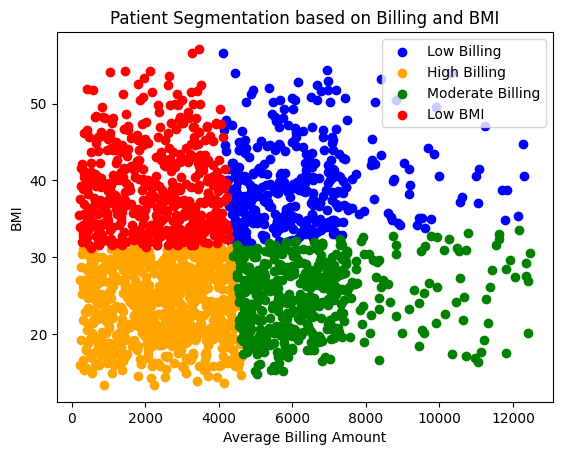

In [42]:
plt.scatter(
    cluster0['Avg_Billing_Amount'],
    cluster0['BMI'],
    color='blue',
    label='Low Billing'
)
plt.scatter(
    cluster1['Avg_Billing_Amount'],
    cluster1['BMI'],
    color='orange',
    label='High Billing'
)
plt.scatter(
    cluster2['Avg_Billing_Amount'],
    cluster2['BMI'],
    color='green',
    label='Moderate Billing'
)
plt.scatter(
    cluster3['Avg_Billing_Amount'],
    cluster3['BMI'],
    color='red',
    label='Low BMI'
)
plt.xlabel('Average Billing Amount')
plt.ylabel('BMI')
plt.title('Patient Segmentation based on Billing and BMI')
plt.legend()
plt.show()


In [44]:
print(
    df.groupby('Cluster')[
        ['Avg_Billing_Amount', 'BMI']
    ].mean()
)

         Avg_Billing_Amount        BMI
Cluster                               
0               6206.218157  39.443360
1               2395.877713  24.053980
2               6560.937778  24.955333
3               2249.944898  38.929592


In [45]:
#intertia
inertia = kmeans.inertia_
print(f'Inertia: {inertia}')

Inertia: 1309.8012521750277


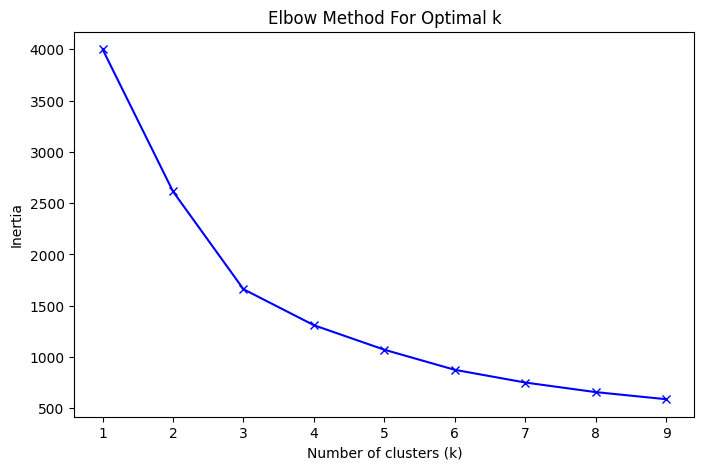

In [46]:
#elbow method to find optimal k
inertia = []
K = range(1, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()


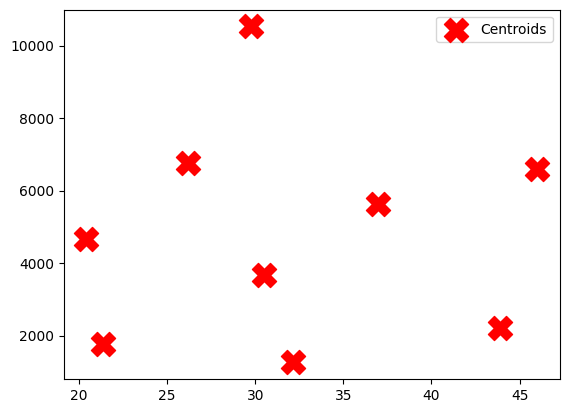

In [49]:
#centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:,1],
    centroids[:,0],
    s=300,
    c='red',
    marker='X',
    label='Centroids'
)
plt.legend()
